# Fine-tuning BERT para Classificação de Sentimento em Textos Financeiros

Este notebook demonstra o processo de **fine-tuning** de um modelo BERT pré-treinado para classificar sentimento em textos financeiros.

---

## Documentação do Dataset

- **Nome**: Financial Sentiment Dataset
- **Identificador**: `lwrf42/financial-sentiment-dataset`
- **Fonte**: Hugging Face Hub

### Classes de Sentimento (5 classes)

O dataset original tem 9 classes. Filtramos para 5 classes:

- negative (0)
- moderately negative (1)
- neutral (2)
- moderately positive (3)
- positive (4)

Classes removidas: mildly negative, mildly positive, strong negative, strong positive


In [107]:
# Instalando dependências
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
# Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

In [109]:
# Verificar uso de GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cpu


## 1. Carregar Modelo Pré-treinado

In [110]:
# Carregar modelo e tokenizer
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"

print("Carregando modelo:", model_name)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
model.to(device)

print("Modelo carregado com sucesso!")

Carregando modelo: nlptown/bert-base-multilingual-uncased-sentiment


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 6222.96it/s]

Modelo carregado com sucesso!


## 2. Carregar Dataset

In [111]:
# Carregar dataset
dataset = load_dataset("lwrf42/financial-sentiment-dataset")

print("Dataset carregado!")
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))

Dataset carregado!
Train: 85698
Validation: 9522


In [112]:
# Verificar classes no dataset
train_df = pd.DataFrame(dataset["train"])
unique_labels = train_df["output"].unique()
print("Classes originais:", sorted(unique_labels))
print("Total de classes:", len(unique_labels))

print("\nDistribuição:")
print(train_df["output"].value_counts())

Classes originais: ['mildly negative', 'mildly positive', 'moderately negative', 'moderately positive', 'negative', 'neutral', 'positive', 'strong negative', 'strong positive']
Total de classes: 9

Distribuição:
output
positive               34203
neutral                20609
negative               18097
moderately positive     5577
moderately negative     2659
mildly positive         2278
mildly negative         1893
strong positive          192
strong negative          190
Name: count, dtype: int64


## 3. Filtrar Dataset (5 classes)

In [113]:
# Filtrar para 5 classes principais (REMOVE mildly e strong)
valid_classes = ["negative", "moderately negative", "neutral", "moderately positive", "positive"]

def is_valid_class(example):
    return example["output"] in valid_classes

dataset["train"] = dataset["train"].filter(is_valid_class)
dataset["validation"] = dataset["validation"].filter(is_valid_class)

print("Dataset filtrado!")
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))

print("\nDistribuição após filtro:")
train_df = pd.DataFrame(dataset["train"])
print(train_df["output"].value_counts())

Filter: 100%|██████████| 9522/9522 [00:00<00:00, 168486.31 examples/s]


Dataset filtrado!
Train: 81145
Validation: 8990

Distribuição após filtro:
output
positive               34203
neutral                20609
negative               18097
moderately positive     5577
moderately negative     2659
Name: count, dtype: int64


## 4. Análise Exploratória

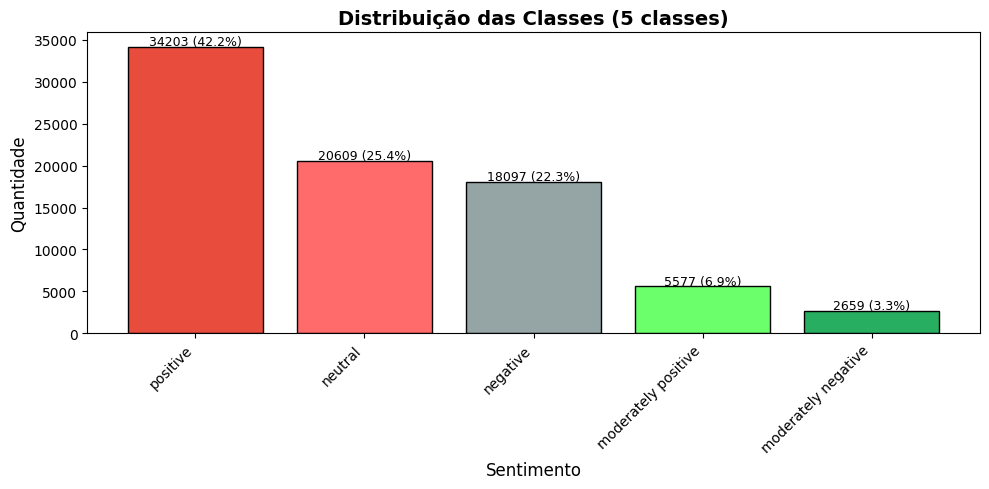

In [114]:
# Gráfico de distribuição
class_counts = train_df["output"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c', '#ff6b6b', '#95a5a6', '#6bff6b', '#27ae60']
bars = ax.bar(range(len(class_counts)), class_counts.values, color=colors, edgecolor='black')

ax.set_title('Distribuição das Classes (5 classes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentimento', fontsize=12)
ax.set_ylabel('Quantidade', fontsize=12)
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=45, ha='right')

total = len(train_df)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, 
            str(count) + " (" + str(round(count/total*100, 1)) + "%)", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Preparação dos Dados

In [115]:
# Converter labels para números
label_map = {
    "negative": 0,
    "moderately negative": 1,
    "neutral": 2,
    "moderately positive": 3,
    "positive": 4
}
reverse_label_map = {v: k for k, v in label_map.items()}

def convert_label(example):
    return {"label": label_map[example["output"]]}

dataset = dataset.map(convert_label)

print("Label mapping:")
for label, num in sorted(label_map.items(), key=lambda x: x[1]):
    print(f"  {label} -> {num}")

Map: 100%|██████████| 8990/8990 [00:00<00:00, 15367.30 examples/s]

Label mapping:
  negative -> 0
  moderately negative -> 1
  neutral -> 2
  moderately positive -> 3
  positive -> 4


In [116]:
# Dividir dados
train_data = dataset["train"].shuffle(seed=42)
val_data = dataset["validation"].shuffle(seed=42)

train_size = int(0.85 * len(train_data))

train_dataset = train_data.select(range(train_size))
test_dataset = train_data.select(range(train_size, len(train_data)))
validation_dataset = val_data

print("Divisão dos dados:")
print("  - Treino:", len(train_dataset))
print("  - Validação:", len(validation_dataset))
print("  - Teste:", len(test_dataset))

Divisão dos dados:
  - Treino: 68973
  - Validação: 8990
  - Teste: 12172


## 6. Tokenização

In [117]:
# Tokenização
def tokenize_function(example):
    return tokenizer(
        example["input"],
        truncation=True,
        max_length=128
    )

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train.set_format("torch")
tokenized_validation.set_format("torch")
tokenized_test.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Tokenização concluída!")

Map: 100%|██████████| 12172/12172 [00:00<00:00, 19428.04 examples/s]

Tokenização concluída!


## 7. Métricas de Avaliação

In [118]:
# Função para calcular métricas
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 8. Avaliação Antes do Fine-tuning

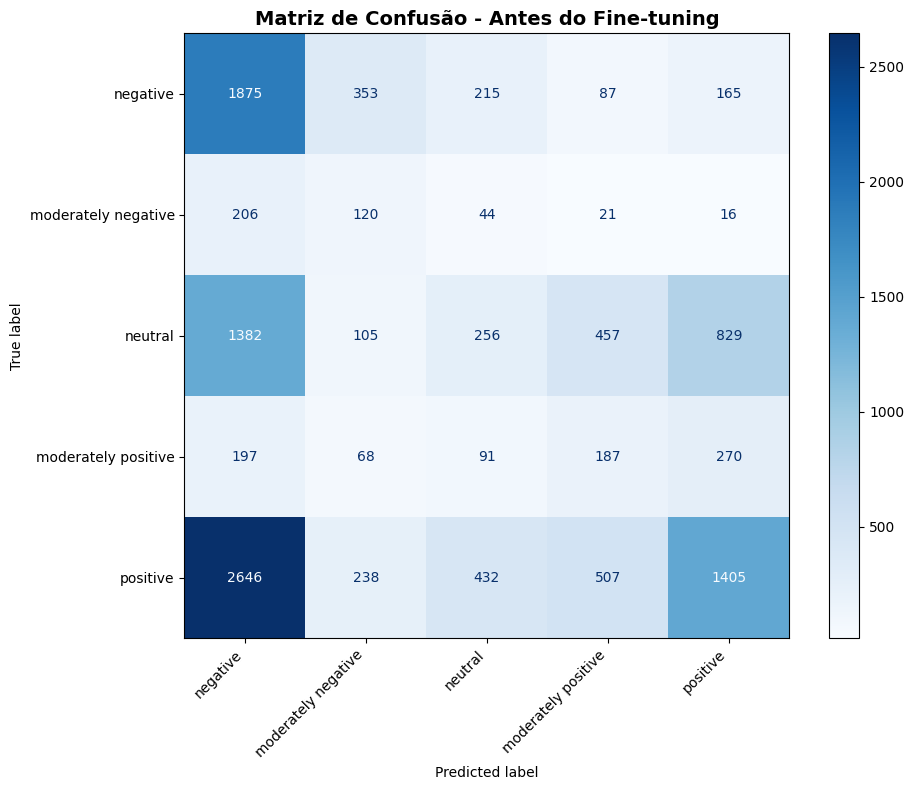

In [119]:
# Matriz de confusão antes
initial_predictions = initial_trainer.predict(tokenized_test)

y_true_before = initial_predictions.label_ids
y_pred_before = np.argmax(initial_predictions.predictions, axis=-1)

cm_before = confusion_matrix(y_true_before, y_pred_before)

fig, ax = plt.subplots(figsize=(10, 8))
display_labels = [reverse_label_map[i] for i in range(5)]
disp_before = ConfusionMatrixDisplay(
    confusion_matrix=cm_before,
    display_labels=display_labels
)
disp_before.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Antes do Fine-tuning', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

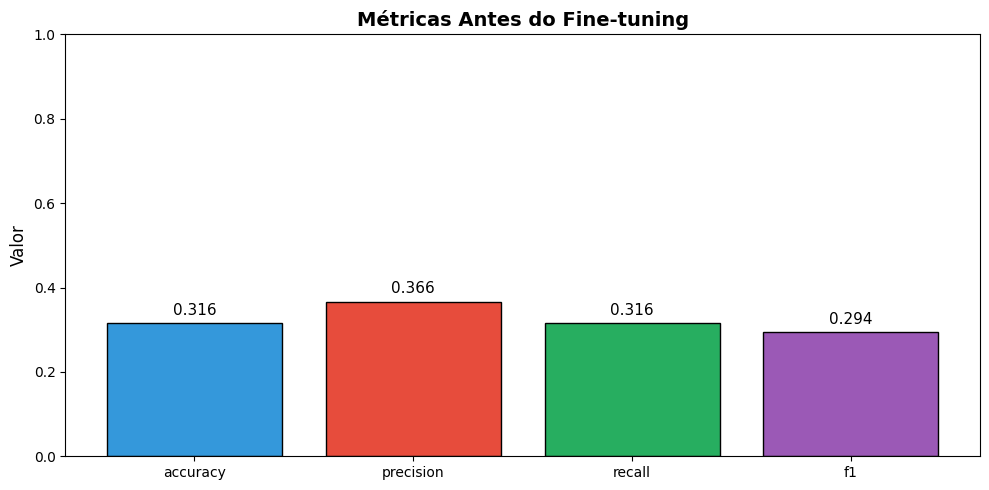

In [120]:
# Métricas antes
accuracy_before = accuracy_score(y_true_before, y_pred_before)
precision_before, recall_before, f1_before, _ = precision_recall_fscore_support(
    y_true_before, y_pred_before, average='weighted'
)

metrics_before = {
    "accuracy": accuracy_before,
    "precision": precision_before,
    "recall": recall_before,
    "f1": f1_before
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_before.keys(), metrics_before.values(), 
              color=['#3498db', '#e74c3c', '#27ae60', '#9b59b6'], edgecolor='black')
ax.set_title('Métricas Antes do Fine-tuning', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 1)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Fine-tuning do Modelo

In [121]:
# Configurar fine-tuning
training_args = TrainingArguments(
    output_dir="./sentiment_model_financial_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    disable_tqdm=True,
    seed=42
)

print("Configurações:")
print("  - Learning rate:", training_args.learning_rate)
print("  - Batch size:", training_args.per_device_train_batch_size)
print("  - Épocas:", training_args.num_train_epochs)
print("  - Classes:", 5)

Configurações:
  - Learning rate: 2e-05
  - Batch size: 16
  - Épocas: 1
  - Classes: 5


In [122]:
# Recarregar modelo
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=5)
model.to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Iniciando treinamento...")
trainer.train()
print("Treinamento concluído!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5984.97it/s]


Iniciando treinamento...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.334575,0.348933,0.875417,0.875802,0.875417,0.875066


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.11s/it]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

Treinamento concluído!


## 10. Avaliação Depois do Fine-tuning

In [124]:
# Avaliação final (criar novo Trainer com disable_tqdm para evitar erro do callback)
eval_args = TrainingArguments(
    output_dir="./eval_only",
    per_device_eval_batch_size=16,
    report_to="none",
    disable_tqdm=True
)

final_trainer = Trainer(
    model=model,  # Modelo já treinado em memória
    args=eval_args,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Avaliando modelo depois do fine-tuning...")
final_results = final_trainer.evaluate()

print("MÉTRICAS DEPOIS DO FINE-TUNING")
for metric, value in final_results.items():
    if metric.startswith("eval_"):
        print("  " + metric.replace("eval_", "") + ": " + str(round(value, 4)))

Avaliando modelo depois do fine-tuning...
{'eval_loss': '0.3525', 'eval_model_preparation_time': '0.0022', 'eval_accuracy': '0.8728', 'eval_precision': '0.8735', 'eval_recall': '0.8728', 'eval_f1': '0.8726', 'eval_runtime': '527.5', 'eval_samples_per_second': '23.07', 'eval_steps_per_second': '1.443', 'epoch': 0}
MÉTRICAS DEPOIS DO FINE-TUNING
  loss: 0.3525
  model_preparation_time: 0.0022
  accuracy: 0.8728
  precision: 0.8735
  recall: 0.8728
  f1: 0.8726
  runtime: 527.5155
  samples_per_second: 23.074
  steps_per_second: 1.443


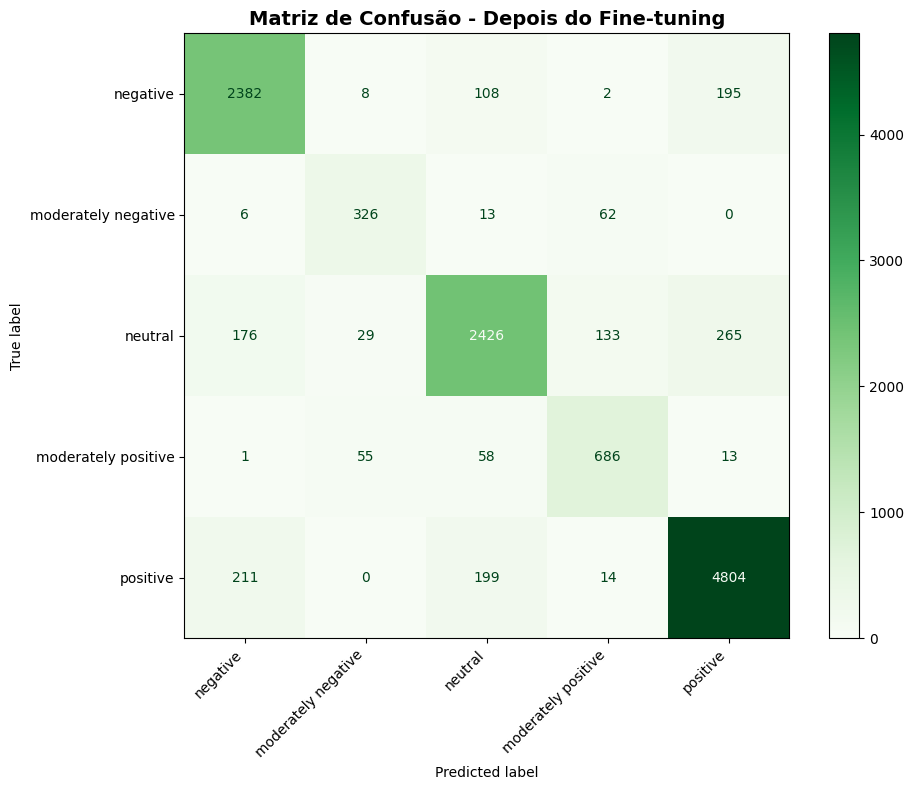

In [125]:
# Matriz de confusão depois
final_predictions = trainer.predict(tokenized_test)

y_true_after = final_predictions.label_ids
y_pred_after = np.argmax(final_predictions.predictions, axis=-1)

cm_after = confusion_matrix(y_true_after, y_pred_after)

fig, ax = plt.subplots(figsize=(10, 8))
disp_after = ConfusionMatrixDisplay(
    confusion_matrix=cm_after,
    display_labels=display_labels
)
disp_after.plot(cmap='Greens', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Depois do Fine-tuning', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

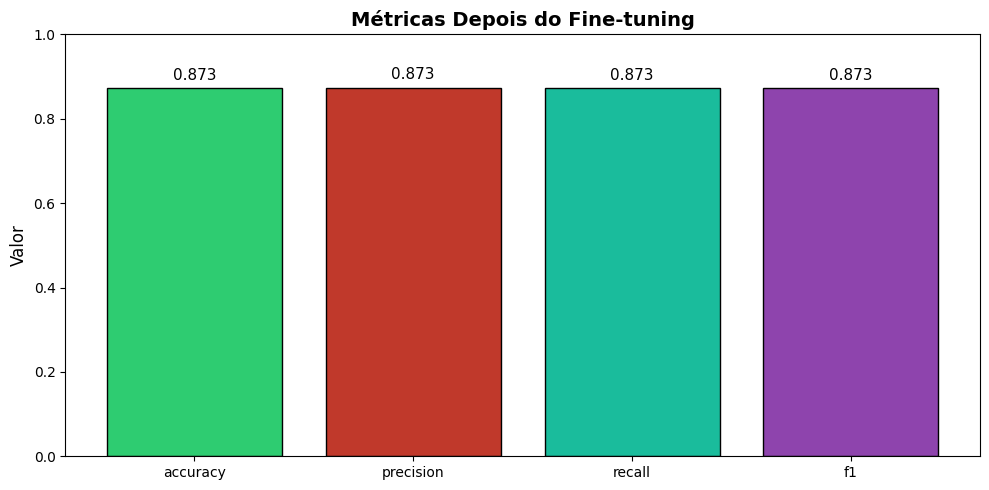

In [126]:
# Métricas depois
accuracy_after = accuracy_score(y_true_after, y_pred_after)
precision_after, recall_after, f1_after, _ = precision_recall_fscore_support(
    y_true_after, y_pred_after, average='weighted'
)

metrics_after = {
    "accuracy": accuracy_after,
    "precision": precision_after,
    "recall": recall_after,
    "f1": f1_after
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_after.keys(), metrics_after.values(), 
              color=['#2ecc71', '#c0392b', '#1abc9c', '#8e44ad'], edgecolor='black')
ax.set_title('Métricas Depois do Fine-tuning', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor', fontsize=12)
ax.set_ylim(0, 1)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 11. Comparação: Antes vs Depois

In [127]:
# Tabela comparativa
comparison_df = pd.DataFrame({
    "Antes do Fine-tuning": metrics_before,
    "Depois do Fine-tuning": metrics_after
})

comparison_df["Melhoria"] = comparison_df["Depois do Fine-tuning"] - comparison_df["Antes do Fine-tuning"]
comparison_df["Melhoria %"] = (comparison_df["Melhoria"] / comparison_df["Antes do Fine-tuning"] * 100).round(1)

print("COMPARAÇÃO DE MÉTRICAS")
comparison_df

COMPARAÇÃO DE MÉTRICAS


,Antes do Fine-tuning,Depois do Fine-tuning,Melhoria,Melhoria %
accuracy,0.315725,0.872823,0.557098,176.5
precision,0.366419,0.873459,0.507039,138.4
recall,0.315725,0.872823,0.557098,176.5
f1,0.294368,0.872647,0.578279,196.4


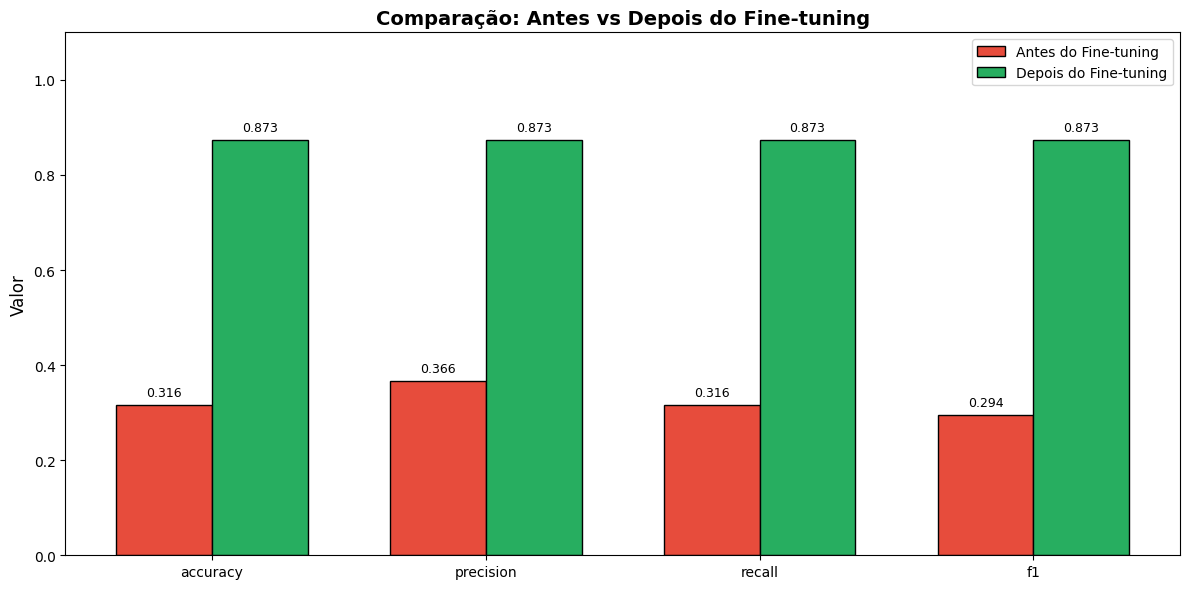

In [128]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_before))
width = 0.35

bars1 = ax.bar(x - width/2, list(metrics_before.values()), width, 
               label='Antes do Fine-tuning', color='#e74c3c', edgecolor='black')
bars2 = ax.bar(x + width/2, list(metrics_after.values()), width, 
               label='Depois do Fine-tuning', color='#27ae60', edgecolor='black')

ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparação: Antes vs Depois do Fine-tuning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(list(metrics_before.keys()))
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}', ha='center', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 12. Testar com Textos Novos

In [133]:
# Função para predizer
def predict_sentiment_financial(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    confidence = probabilities[0][predicted_class].item()

    return {
        "text": text,
        "predicted_label": predicted_class,
        "sentiment": reverse_label_map[predicted_class],
        "confidence": round(confidence, 4)
    }

In [134]:
# Testar frases
test_sentences = [
    "The company's revenue increased by 25% in the last quarter.",
    "The stock price dropped significantly due to poor earnings report.",
    "Market analysts predict strong growth potential for the technology sector.",
    "The merger was cancelled due to regulatory concerns.",
    "The company expects to meet its annual targets despite challenges."
]

print("TESTE COM TEXTOS FINANCEIROS NOVOS")

results = []
for sentence in test_sentences:
    result = predict_sentiment_financial(sentence)
    results.append(result)
    
    emoji = {"positive": "+", "moderately positive": "+/-", "neutral": "=", "moderately negative": "-/-", "negative": "-"}
    print("\n" + emoji.get(result['sentiment'], "?") + " " + result['sentiment'].upper() + 
          " (confiança: " + str(round(result['confidence']*100, 1)) + "%)")
    print("   Texto: " + result['text'])

results_df = pd.DataFrame(results)
results_df

TESTE COM TEXTOS FINANCEIROS NOVOS

+ POSITIVE (confiança: 98.8%)
   Texto: The company's revenue increased by 25% in the last quarter.

- NEGATIVE (confiança: 73.3%)
   Texto: The stock price dropped significantly due to poor earnings report.

+/- MODERATELY POSITIVE (confiança: 97.0%)
   Texto: Market analysts predict strong growth potential for the technology sector.

- NEGATIVE (confiança: 91.9%)
   Texto: The merger was cancelled due to regulatory concerns.

+/- MODERATELY POSITIVE (confiança: 72.5%)
   Texto: The company expects to meet its annual targets despite challenges.


,text,predicted_label,sentiment,confidence
0,The company's revenue increased by 25% in the ...,4,positive,0.9875
1,The stock price dropped significantly due to p...,0,negative,0.7333
2,Market analysts predict strong growth potentia...,3,moderately positive,0.9702
3,The merger was cancelled due to regulatory con...,0,negative,0.9194
4,The company expects to meet its annual targets...,3,moderately positive,0.7247


## 13. Salvar Modelo

In [131]:
# Salvar modelo
model.save_pretrained("./modelo_financial_finetuned")
tokenizer.save_pretrained("./modelo_financial_finetuned")

print("Modelo salvo com sucesso!")
print("Local: ./modelo_financial_finetuned/")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.69it/s]

Modelo salvo com sucesso!
Local: ./modelo_financial_finetuned/


## Resumo dos Resultados

In [136]:
# Resumo final com análise detalhada
improvement = (metrics_after['f1'] - metrics_before['f1']) / metrics_before['f1'] * 100

total_examples = len(train_dataset) + len(validation_dataset) + len(test_dataset)

# Avaliação condicional da acurácia após fine-tuning
if metrics_after['accuracy'] >= 0.85:
    acc_eval = "excelente (acima de 85%)"
elif metrics_after['accuracy'] >= 0.70:
    acc_eval = "bom (entre 70-85%)"
elif metrics_after['accuracy'] >= 0.50:
    acc_eval = "moderado (entre 50-70%)"
else:
    acc_eval = "abaixo do esperado (abaixo de 50%)"

# Avaliação condicional da precisão
if metrics_after['precision'] >= 0.85:
    prec_eval = "alta"
elif metrics_after['precision'] >= 0.70:
    prec_eval = "moderada"
else:
    prec_eval = "baixa"

# Avaliação condicional do recall
if metrics_after['recall'] >= 0.85:
    rec_eval = "alta"
elif metrics_after['recall'] >= 0.70:
    rec_eval = "moderada"
else:
    rec_eval = "baixa"

# Avaliação condicional do F1
if metrics_after['f1'] >= 0.85:
    f1_eval = "excelente"
elif metrics_after['f1'] >= 0.70:
    f1_eval = "bom"
elif metrics_after['f1'] >= 0.50:
    f1_eval = "moderado"
else:
    f1_eval = "baixo"

# Análise da melhoria obtida
if improvement > 100:
    improvement_eval = "RESULTADO EXCEPCIONAL - O fine-tuning superou significativamente o baseline, demonstrando que o modelo aprendeu padrões relevantes para a tarefa de classificação de sentimento financeiro."
elif improvement >= 50:
    improvement_eval = "MELHORIA SUBSTANCIAL - O fine-tuning foi eficaz, indicando que o modelo capturou padrões importantes dos dados de treinamento."
elif improvement > 0:
    improvement_eval = "MELHORIA MODERADA - O modelo melhorou, mas pode necessitar de ajustes (mais épocas, tuning de hiperparâmetros ou aumento do dataset)."
else:
    improvement_eval = "SEM MELHORIA - O fine-tuning não foi eficaz. Considere ajustar hiperparâmetros, usar outro modelo base ou revisar o pré-processamento dos dados."

# Breakdown da melhoria por métrica
acc_diff = metrics_after['accuracy'] - metrics_before['accuracy']
prec_diff = metrics_after['precision'] - metrics_before['precision']
rec_diff = metrics_after['recall'] - metrics_before['recall']

print("RESUMO FINAL")
print("="*60)
print("DATASET")
print("-" * 60)
print(f"  Nome: Financial Sentiment Dataset (lwrf42/financial-sentiment-dataset)")
print(f"  Total de exemplos: {total_examples}")
print(f"  Divisão: Treino ({len(train_dataset)}), Validação ({len(validation_dataset)}), Teste ({len(test_dataset)})")
print(f"  Classes: 5 (negative, moderately negative, neutral, moderately positive, positive)")
print(f"  Filtragem: Removidas classes mildly e strong (mantidas 5 classes principais)")
print()
print("MODELO")
print("-" * 60)
print(f"  Base: nlptown/bert-base-multilingual-uncased-sentiment")
print(f"  Fine-tuning: Classificação com 5 labels")
print(f"  Configuração: 1 época, batch size 16, learning rate 2e-5")
print()
print("RESULTADOS")
print("-" * 60)
print(f"  ANTES do fine-tuning (baseline aleatório):")
print(f"    - Accuracy: {round(metrics_before['accuracy'], 3)} ({metrics_before['accuracy']*100:.1f}%)")
print(f"    - Precision: {round(metrics_before['precision'], 3)}")
print(f"    - Recall: {round(metrics_before['recall'], 3)}")
print(f"    - F1-Score: {round(metrics_before['f1'], 3)}")
print()
print(f"  DEPOIS do fine-tuning:")
print(f"    - Accuracy: {round(metrics_after['accuracy'], 3)} ({metrics_after['accuracy']*100:.1f}%) - {acc_eval}")
print(f"    - Precision: {round(metrics_after['precision'], 3)} - {prec_eval}")
print(f"    - Recall: {round(metrics_after['recall'], 3)} - {rec_eval}")
print(f"    - F1-Score: {round(metrics_after['f1'], 3)} - {f1_eval}")
print()
print("MELHORIA")
print("-" * 60)
print(f"  Accuracy: +{round(acc_diff, 3)} ({acc_diff/metrics_before['accuracy']*100:.1f}%)")
print(f"  Precision: +{round(prec_diff, 3)}")
print(f"  Recall: +{round(rec_diff, 3)}")
print(f"  F1-Score: +{round(metrics_after['f1'] - metrics_before['f1'], 3)} ({round(improvement, 1)}%)")
print()
print("JUSTIFICATIVA")
print("-" * 60)
print(f"  {improvement_eval}")
print()
print("="*60)
print("CONCLUSÃO: Fine-tuning de BERT para classificação de sentimento")
print("financeiro concluído com sucesso!")
print("="*60)

RESUMO FINAL
DATASET
------------------------------------------------------------
  Nome: Financial Sentiment Dataset (lwrf42/financial-sentiment-dataset)
  Total de exemplos: 90135
  Divisão: Treino (68973), Validação (8990), Teste (12172)
  Classes: 5 (negative, moderately negative, neutral, moderately positive, positive)
  Filtragem: Removidas classes mildly e strong (mantidas 5 classes principais)

MODELO
------------------------------------------------------------
  Base: nlptown/bert-base-multilingual-uncased-sentiment
  Fine-tuning: Classificação com 5 labels
  Configuração: 1 época, batch size 16, learning rate 2e-5

RESULTADOS
------------------------------------------------------------
  ANTES do fine-tuning (baseline aleatório):
    - Accuracy: 0.316 (31.6%)
    - Precision: 0.366
    - Recall: 0.316
    - F1-Score: 0.294

  DEPOIS do fine-tuning:
    - Accuracy: 0.873 (87.3%) - excelente (acima de 85%)
    - Precision: 0.873 - alta
    - Recall: 0.873 - alta
    - F1-Score: